# Getting Started with nestkit

This notebook demonstrates the core functionality of **nestkit**  -  a rigorous nested cross-validation toolkit for scikit-learn.

## What you'll learn

1. How to run nested CV for binary classification
2. How to inspect and interpret results
3. How to create basic visualizations
4. How to add probability calibration
5. How to add threshold optimization
6. How to run nested CV for regression with prediction intervals

## Prerequisites

```bash
pip install nestkit[plotting]
```

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge

from nestkit import NestedCVClassifier, NestedCVRegressor
from nestkit.plotting import (
    plot_calibration_curves,
    plot_calibration_improvement,
    plot_confusion_matrices,
    plot_inner_cv_heatmap,
    plot_outer_scores,
    plot_param_selection,
    plot_precision_recall_curves,
    plot_predicted_vs_actual,
    plot_prediction_intervals,
    plot_residual_qq,
    plot_residuals,
    plot_roc_curves,
    plot_score_stability,
    plot_threshold_comparison,
    plot_threshold_distribution,
    plot_threshold_sensitivity,
)

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Binary Classification with NestedCVClassifier

We'll use the **breast cancer** dataset (569 samples, 30 features, binary target) to demonstrate nested CV for classification.

Standard cross-validation conflates model selection with performance estimation, producing optimistically biased scores. **Nested CV** separates the two:
- **Inner loop**  -  hyperparameter tuning on the outer training set
- **Outer loop**  -  unbiased evaluation on the held-out outer test fold

In [2]:
X, y = load_breast_cancer(return_X_y=True)
feature_names = list(load_breast_cancer().feature_names)
print(f"Shape: {X.shape}")
print(f"Classes: {np.unique(y)}, counts: {np.bincount(y)}")

Shape: (569, 30)
Classes: [0 1], counts: [212 357]


In [3]:
ncv = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10]},
    outer_cv=5,
    inner_cv=3,
    scoring="roc_auc",
    random_state=42,
)
ncv.fit(X, y)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,search_strategy,'grid'
,outer_cv,5
,inner_cv,3
,scoring,'roc_auc'
,refit,True
,return_train_score,False
,return_estimator,True
,error_score,'raise'
,n_jobs_outer,None


## 2. Inspecting Results

After fitting, `ncv.results_` returns a `ClassifierResults` object with summary statistics, per-fold predictions, best hyperparameters, and generalization gap analysis.

In [4]:
results = ncv.results_
results.summary_default_

,metric,mean,std,ci_lower,ci_upper,median,iqr
0,accuracy,0.959618,0.028121,0.907243,1.011993,0.973684,0.043704
1,balanced_accuracy,0.955556,0.032409,0.895194,1.015918,0.969246,0.057960
2,precision,0.964525,0.032206,0.904540,1.024509,0.972603,0.043254
3,recall,0.971909,0.024452,0.926368,1.017450,0.985915,0.014280
4,f1,0.967937,0.022510,0.926013,1.009862,0.979310,0.033333
5,roc_auc,0.990150,0.009537,0.972387,1.007913,0.991733,0.014053


In [5]:
print("Best hyperparameters per fold:")
for i, params in enumerate(results.best_params_per_fold_):
    print(f"  Fold {i}: {params}")

print("\nParameter stability:")
results.param_stability_

Best hyperparameters per fold:
  Fold 0: {'max_depth': 10, 'n_estimators': 50}
  Fold 1: {'max_depth': 5, 'n_estimators': 100}
  Fold 2: {'max_depth': 5, 'n_estimators': 200}
  Fold 3: {'max_depth': 5, 'n_estimators': 200}
  Fold 4: {'max_depth': 5, 'n_estimators': 100}

Parameter stability:


,parameter,mode,nunique,agreement_rate
0,max_depth,5,2,0.8
1,n_estimators,100,3,0.4


In [6]:
# Out-of-fold predictions  -  each sample appears exactly once as a test sample
results.predictions_.head(10)

,y_true,y_pred_default,fold_idx,y_proba_raw_0,y_proba_raw_1
0,0,0,0,0.86,0.14
1,0,0,0,0.94,0.06
2,0,0,0,1.00,0.00
3,0,0,0,0.74,0.26
4,0,0,0,0.84,0.16
5,0,0,0,0.72,0.28
6,0,0,0,1.00,0.00
7,0,0,0,0.92,0.08
8,0,0,0,0.94,0.06
9,0,0,0,0.78,0.22


In [7]:
# Generalization gap: difference between inner CV score and outer test score
results.generalization_gap_

,fold_idx,best_inner_score,outer_accuracy,gap_accuracy,outer_balanced_accuracy,gap_balanced_accuracy,outer_precision,gap_precision,outer_recall,gap_recall,outer_f1,gap_f1,outer_roc_auc,gap_roc_auc
0,0,0.990890,0.921053,0.069837,0.918277,0.072613,0.942857,0.048032,0.929577,0.061312,0.936170,0.054719,0.976744,0.014145
1,1,0.993727,0.938596,0.055131,0.923190,0.070537,0.921053,0.072675,0.985915,0.007812,0.952381,0.041346,0.984605,0.009122
2,2,0.988471,0.982456,0.006015,0.981151,0.007320,0.986111,0.002360,0.986111,0.002360,0.986111,0.002360,0.999008,-0.010537
3,3,0.993157,0.973684,0.019473,0.969246,0.023911,0.972603,0.020554,0.986111,0.007046,0.979310,0.013847,0.991733,0.001424
4,4,0.990807,0.982301,0.008506,0.985915,0.004891,1.000000,-0.009193,0.971831,0.018976,0.985714,0.005093,0.998659,-0.007852


In [8]:
# Pooled classification report across all outer folds
print(results.classification_report_pooled())

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       212
           1       0.96      0.97      0.97       357

    accuracy                           0.96       569
   macro avg       0.96      0.96      0.96       569
weighted avg       0.96      0.96      0.96       569



## 3. Plotting

nestkit provides 25+ plotting functions. All accept an optional `ax` parameter for embedding in custom figure layouts.

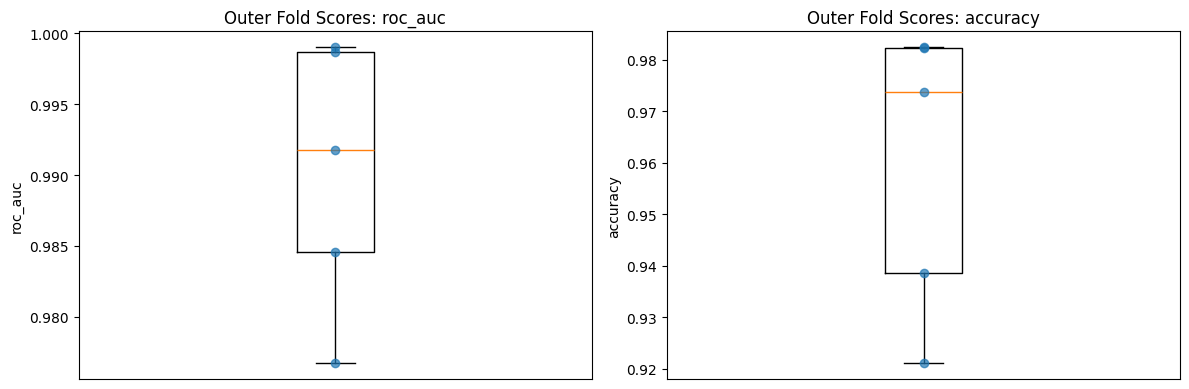

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_outer_scores(results, "roc_auc", ax=axes[0])
plot_outer_scores(results, "accuracy", ax=axes[1])
plt.tight_layout()

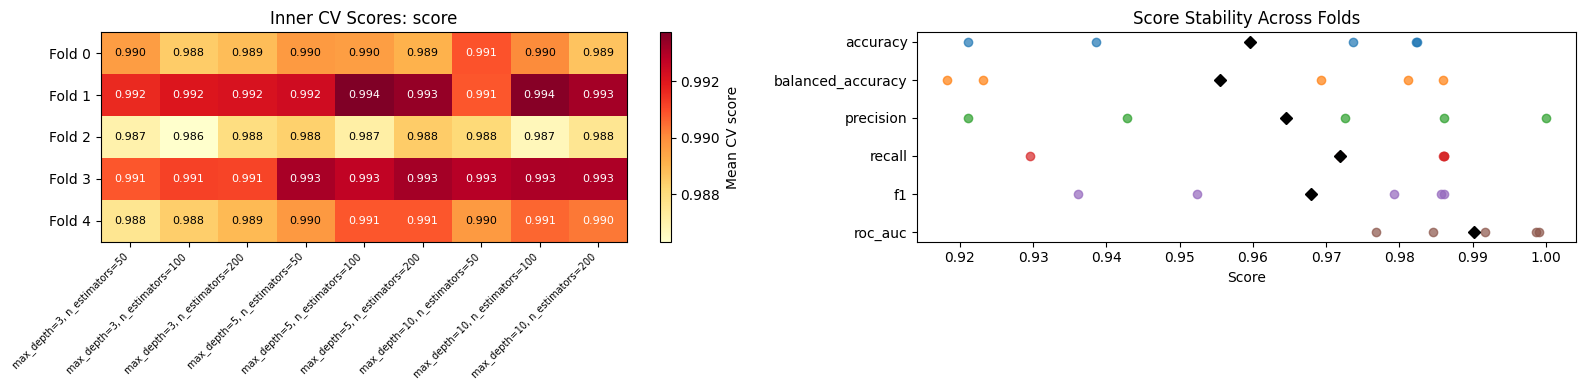

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_inner_cv_heatmap(results, ax=axes[0])
plot_score_stability(results, ax=axes[1])
plt.tight_layout()

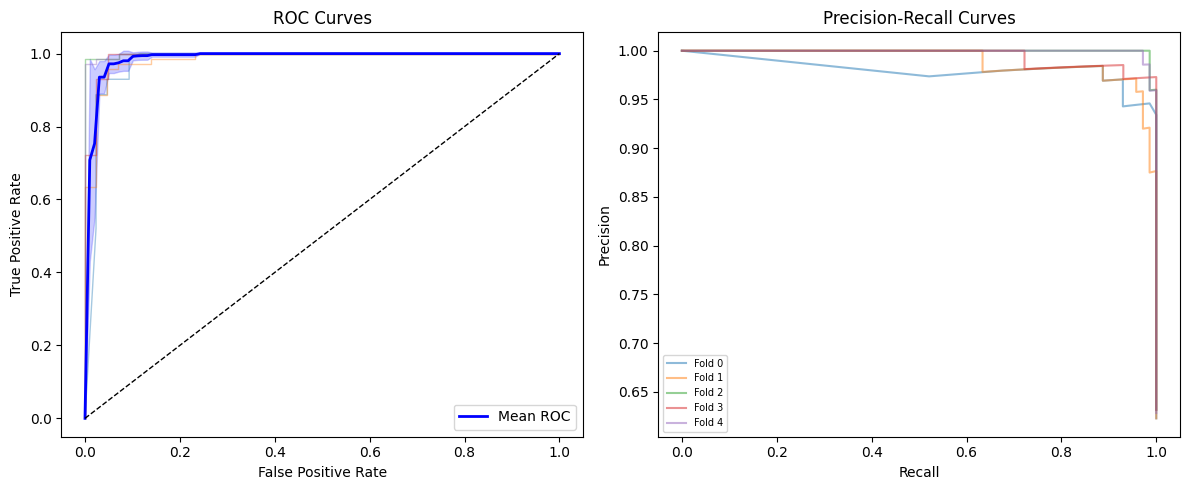

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_roc_curves(results, ax=axes[0])
plot_precision_recall_curves(results, ax=axes[1])
plt.tight_layout()

<Axes: title={'center': 'Fold 0'}, xlabel='Predicted', ylabel='True'>

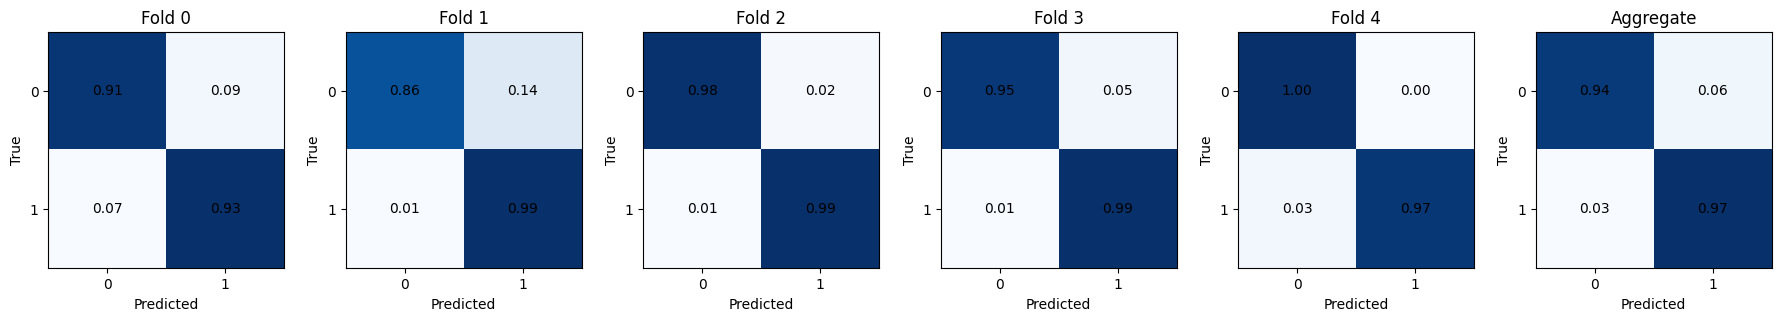

In [12]:
plot_confusion_matrices(results, normalize="true")

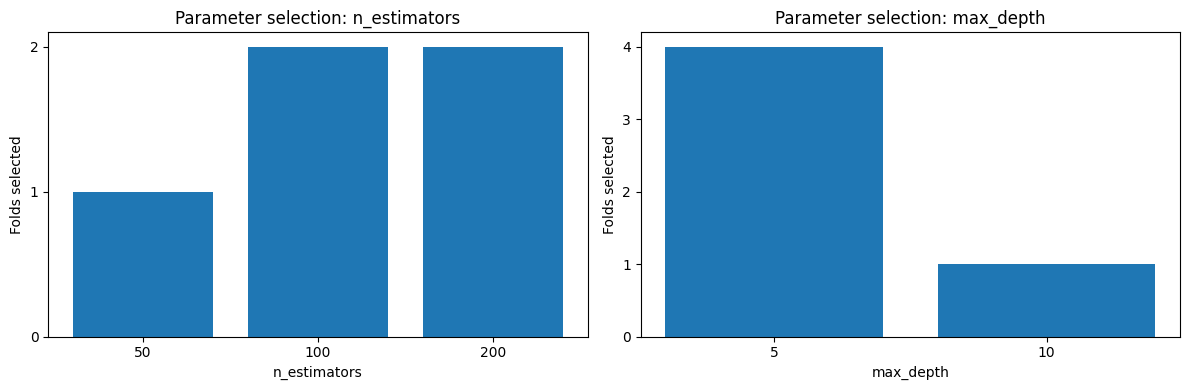

In [13]:
# Which hyperparameters were selected across folds?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_param_selection(results, "n_estimators", ax=axes[0])
plot_param_selection(results, "max_depth", ax=axes[1])
plt.tight_layout()

## 4. Adding Probability Calibration

Many classifiers produce poorly calibrated probabilities  -  a predicted probability of 0.8 doesn't mean the event occurs 80% of the time. nestkit supports four post-hoc calibration methods:

- `"sigmoid"`  -  Platt scaling (logistic regression on raw probabilities)
- `"isotonic"`  -  Isotonic regression (non-parametric)
- `"beta"`  -  Beta calibration
- `"venn-abers"`  -  Venn-ABERS prediction

Calibration is performed using out-of-fold (OOF) predictions from the inner CV to avoid data leakage.

In [14]:
ncv_cal = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10]},
    outer_cv=5,
    inner_cv=3,
    scoring="roc_auc",
    calibration_method="isotonic",
    random_state=42,
)
ncv_cal.fit(X, y)
results_cal = ncv_cal.results_

In [15]:
print(f"Has calibration: {results_cal.has_calibration}")
print("\nCalibration summary (per-fold ECE, Brier scores):")
display(results_cal.calibration_summary_)
print("\nCalibration improvement (delta = raw - calibrated, positive = improvement):")
display(results_cal.calibration_improvement_)

Has calibration: True

Calibration summary (per-fold ECE, Brier scores):


,fold_idx,ece_raw,ece_calibrated,mce_raw,mce_calibrated,brier_raw,brier_calibrated
0,0,0.042456,0.019309,0.152000,0.175926,0.043832,0.045787
1,1,0.040486,0.052332,0.205041,0.344236,0.045089,0.054155
2,2,0.040498,0.016296,0.142264,0.080141,0.019292,0.015467
3,3,0.031108,0.007254,0.139114,0.011426,0.030284,0.028567
4,4,0.042710,0.019833,0.201191,0.244089,0.020169,0.016963



Calibration improvement (delta = raw - calibrated, positive = improvement):


,fold_idx,delta_ece,delta_brier
0,0.0,0.023147,-0.001955
1,1.0,-0.011845,-0.009066
2,2.0,0.024202,0.003825
3,3.0,0.023854,0.001717
4,4.0,0.022878,0.003206


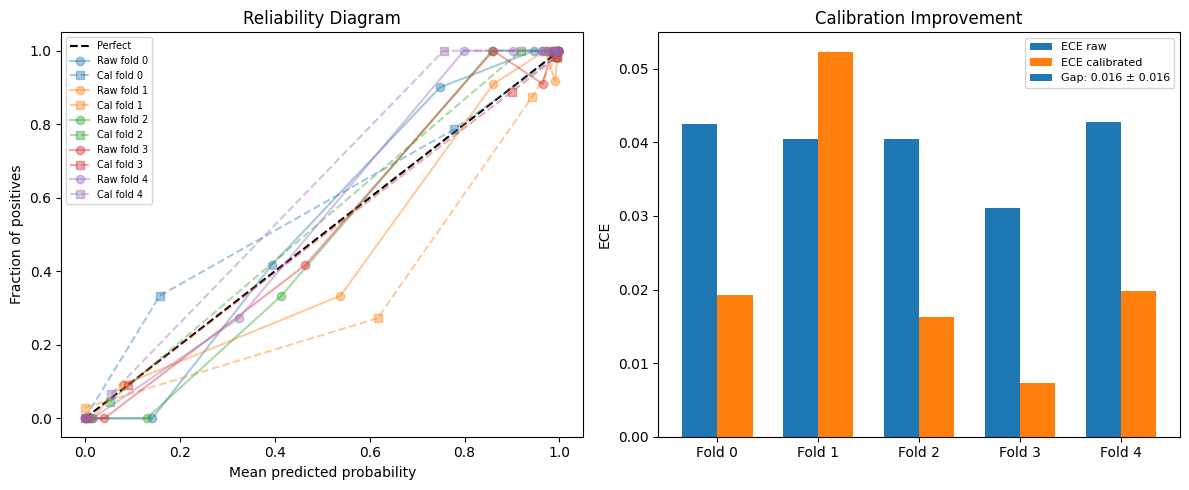

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_calibration_curves(results_cal, ax=axes[0])
plot_calibration_improvement(results_cal, ax=axes[1])
plt.tight_layout()

## 5. Adding Threshold Optimization

The default decision threshold of 0.5 is often suboptimal. nestkit can select an optimal threshold using several criteria:

- `"youden"`  -  Maximizes Youden's J statistic (sensitivity + specificity - 1)
- `"f_beta"`  -  Maximizes F-beta score
- `"cost"`  -  Minimizes expected cost given a cost matrix
- `"balanced_accuracy"`  -  Maximizes balanced accuracy
- `"precision_at_recall"`  -  Maximizes precision subject to a minimum recall

Two strategies are available:
- `"pooled"`  -  A single threshold selected from all OOF predictions
- `"fold_specific"`  -  A separate threshold per outer fold

In [17]:
ncv_thr = NestedCVClassifier(
    estimator=RandomForestClassifier(random_state=42),
    param_grid={"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10]},
    outer_cv=5,
    inner_cv=3,
    scoring="roc_auc",
    calibration_method="isotonic",
    threshold_strategy="pooled",
    threshold_criterion="youden",
    random_state=42,
)
ncv_thr.fit(X, y)
results_thr = ncv_thr.results_

In [18]:
print(f"Threshold optimization: {results_thr.has_threshold_optimization}")
print(f"\nThresholds per fold: {results_thr.thresholds_per_fold_}")
print(f"\nThreshold stability: {results_thr.threshold_stability_}")

Threshold optimization: True

Thresholds per fold: [0.6009697  0.5009899  0.44456566 0.41684848 0.5009899 ]

Threshold stability: {'mean': 0.4928727272727273, 'std': 0.07058680883762491, 'cv': 0.14321508359382815, 'range': 0.18412121212121219}


In [19]:
# Side-by-side comparison: default (0.5) vs optimized threshold
results_thr.threshold_comparison()

,metric,mean_default,std_default,mean_optimized,std_optimized
0,accuracy,0.959603,0.020154,0.954339,0.028655
1,balanced_accuracy,0.953631,0.024760,0.953184,0.029577
2,precision,0.959211,0.026155,0.969723,0.029835
3,recall,0.977582,0.012588,0.957864,0.041130
4,f1,0.968157,0.015799,0.963120,0.024000
5,roc_auc,0.986868,0.012304,0.986868,0.012304


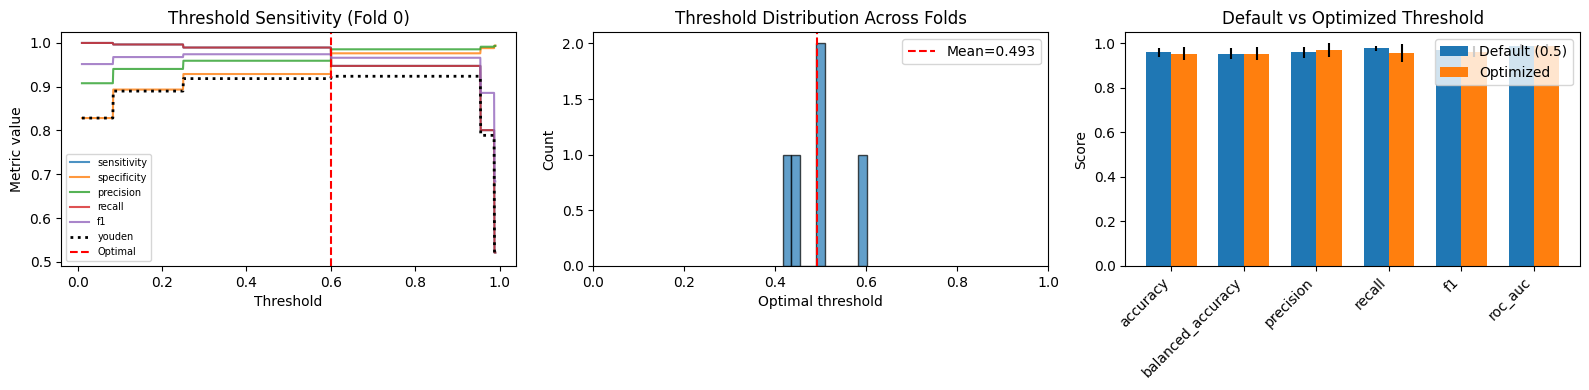

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_threshold_sensitivity(results_thr, fold_idx=0, ax=axes[0])
plot_threshold_distribution(results_thr, bins=10, full_range=True, ax=axes[1])
plot_threshold_comparison(results_thr, ax=axes[2])
plt.tight_layout()

<Axes: title={'center': 'Fold 0'}, xlabel='Predicted', ylabel='True'>

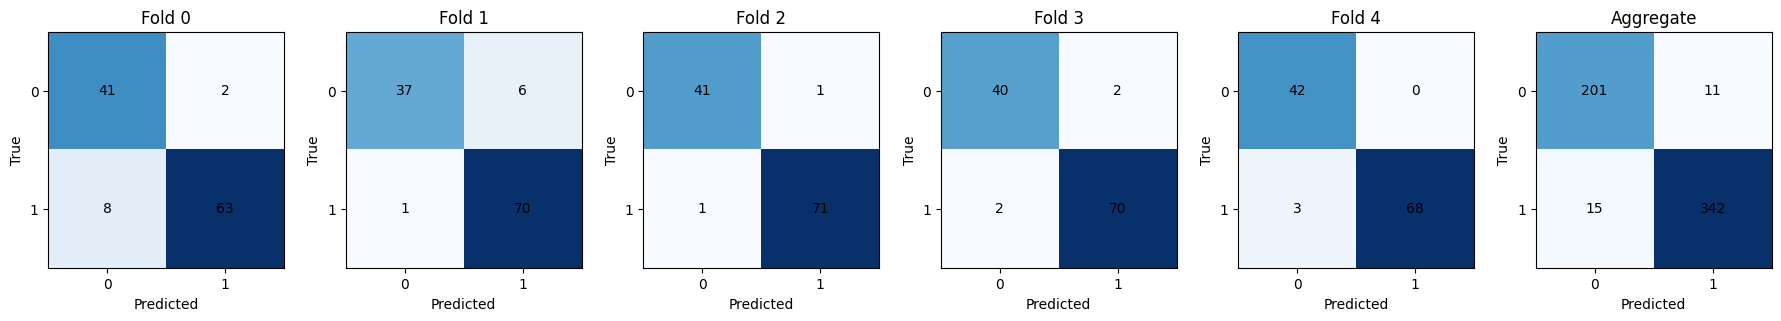

In [21]:
# Confusion matrices with optimized threshold
plot_confusion_matrices(results_thr, threshold="optimized")

## 6. Regression with NestedCVRegressor

nestkit also supports regression tasks. `NestedCVRegressor` provides the same nested CV framework with optional **residual-based prediction intervals**  -  uncertainty estimates derived from the distribution of inner CV residuals.

In [22]:
X_reg, y_reg = load_diabetes(return_X_y=True)
print(f"Shape: {X_reg.shape}, target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")

Shape: (442, 10), target range: [25, 346]


In [23]:
ncv_reg = NestedCVRegressor(
    estimator=Ridge(),
    param_grid={"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    outer_cv=5,
    inner_cv=3,
    prediction_intervals=True,
    random_state=42,
)
ncv_reg.fit(X_reg, y_reg)
results_reg = ncv_reg.results_

In [24]:
print("Summary:")
display(results_reg.summary_default_)
print(f"\nResidual stats: {results_reg.residual_stats_}")
print(f"\nPrediction interval coverage: {results_reg.prediction_interval_coverage_}")

Summary:


,metric,mean,std,ci_lower,ci_upper,median,iqr
0,mse,2997.691750,143.786002,2729.890897,3265.492603,3001.755668,104.319504
1,rmse,54.738582,1.313080,52.292975,57.184189,54.788280,0.953475
2,mae,44.294273,2.179699,40.234593,48.353953,43.292787,2.100991
3,r2,0.481443,0.054231,0.380438,0.582447,0.489191,0.092220
4,mape,0.394409,0.032817,0.333288,0.455530,0.391332,0.044576



Residual stats: {'mean': 0.37101618492788285, 'std': 54.80893629831313, 'median': -2.1691076714726307, 'skewness': 0.05688818733292645, 'kurtosis': -0.2869504563698184}

Prediction interval coverage: {'mean': 0.9547242083758938, 'per_fold': [0.9550561797752809, 0.9662921348314607, 0.9659090909090909, 0.9204545454545454, 0.9659090909090909]}


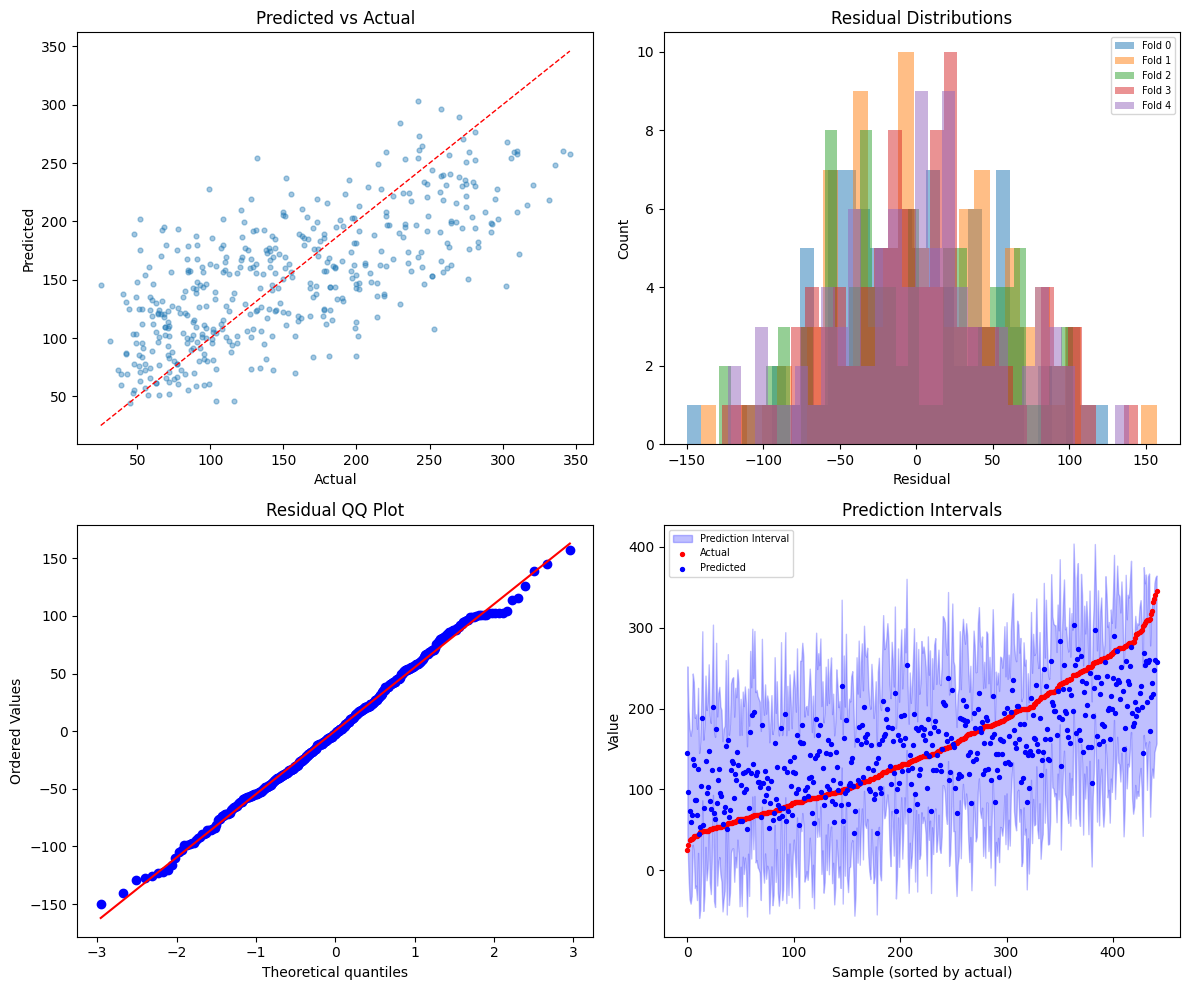

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_predicted_vs_actual(results_reg, ax=axes[0, 0])
plot_residuals(results_reg, ax=axes[0, 1])
plot_residual_qq(results_reg, ax=axes[1, 0])
plot_prediction_intervals(results_reg, ax=axes[1, 1])
plt.tight_layout()

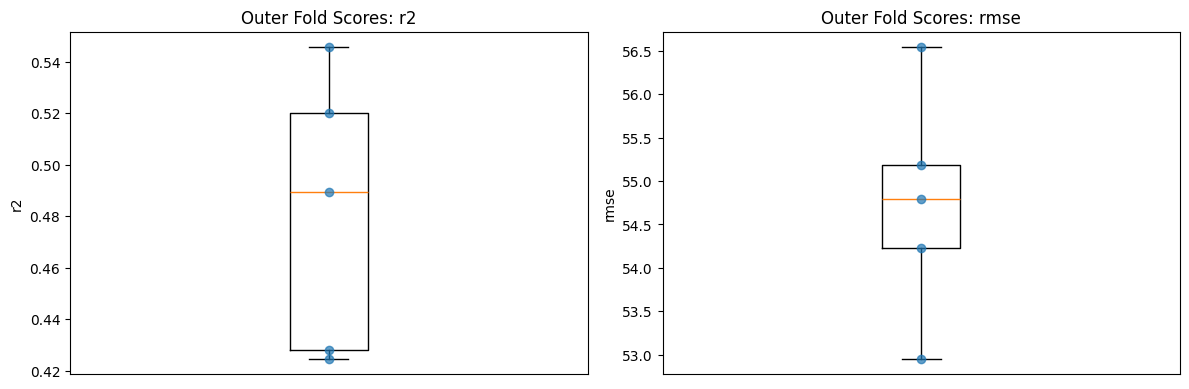

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_outer_scores(results_reg, "r2", ax=axes[0])
plot_outer_scores(results_reg, "rmse", ax=axes[1])
plt.tight_layout()

## Next Steps

This notebook covered the core nestkit workflow. For advanced topics, see **[02  -  Advanced Workflows](02_advanced_workflows.ipynb)**:

- Multi-model statistical comparison with `NestedCVComparator`
- Feature importance aggregation with `FeatureImportanceAggregator`
- Hyperparameter stability diagnostics
- Callbacks and persistence